In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [3]:
np.random.seed(42)

# Generate x values
X = np.sort(np.random.rand(40) * 2 * np.pi)

# Generate sine values
y_true = np.sin(X)

# Add noise
noise = np.random.normal(0, 0.2, len(X))
y = y_true + noise

# Reshape for sklearn
X = X.reshape(-1, 1)

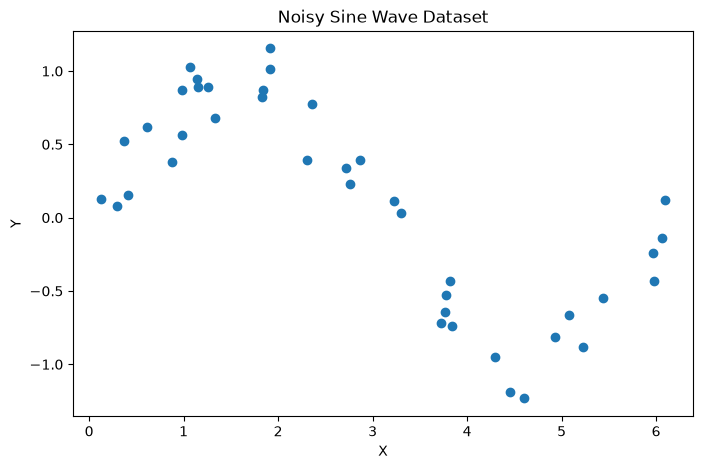

In [4]:
plt.figure(figsize=(8,5))

plt.scatter(X, y)

plt.title("Noisy Sine Wave Dataset")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [7]:
X_plot = np.linspace(0, 2*np.pi, 500).reshape(-1, 1)

In [8]:
model_deg1 = make_pipeline(
    PolynomialFeatures(1),
    LinearRegression()
)

model_deg1.fit(X_train, y_train)

y_pred_deg1 = model_deg1.predict(X_plot)

In [9]:
model_deg4 = make_pipeline(
    PolynomialFeatures(4),
    LinearRegression()
)

model_deg4.fit(X_train, y_train)

y_pred_deg4 = model_deg4.predict(X_plot)

In [10]:
model_deg15 = make_pipeline(
    PolynomialFeatures(15),
    LinearRegression()
)

model_deg15.fit(X_train, y_train)

y_pred_deg15 = model_deg15.predict(X_plot)

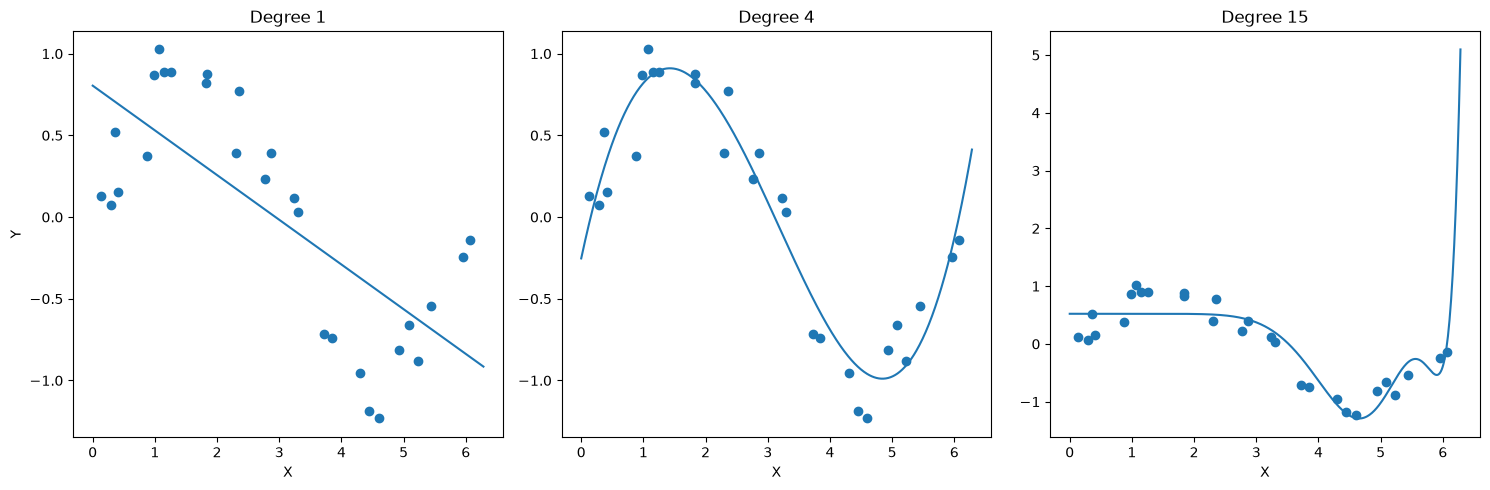

In [11]:
plt.figure(figsize=(15,5))

# Degree 1
plt.subplot(1,3,1)

plt.scatter(X_train, y_train)
plt.plot(X_plot, y_pred_deg1)

plt.title("Degree 1")
plt.xlabel("X")
plt.ylabel("Y")

# Degree 4
plt.subplot(1,3,2)

plt.scatter(X_train, y_train)
plt.plot(X_plot, y_pred_deg4)

plt.title("Degree 4")
plt.xlabel("X")

# Degree 15
plt.subplot(1,3,3)

plt.scatter(X_train, y_train)
plt.plot(X_plot, y_pred_deg15)

plt.title("Degree 15")
plt.xlabel("X")

plt.tight_layout()
plt.show()

In [12]:
### Interpretation

#Degree 1 is too simple and cannot capture the sine-wave pattern.
#This is called underfitting.

#Degree 4 follows the overall trend of the data and provides a good balance between simplicity and flexibility.

#Degree 15 becomes highly complex and starts fitting random noise in the training data.
#This is an example of overfitting.

In [13]:
degrees = range(1, 21)

train_errors = []
validation_errors = []

In [14]:
for degree in degrees:

    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    train_mse = mean_squared_error(y_train, train_pred)
    val_mse = mean_squared_error(y_val, val_pred)

    train_errors.append(train_mse)
    validation_errors.append(val_mse)

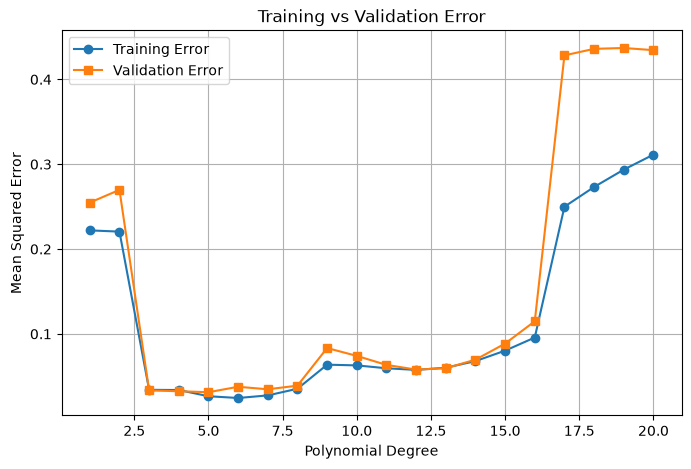

In [15]:
plt.figure(figsize=(8,5))

plt.plot(
    degrees,
    train_errors,
    marker='o',
    label='Training Error'
)

plt.plot(
    degrees,
    validation_errors,
    marker='s',
    label='Validation Error'
)

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Training vs Validation Error")

plt.legend()
plt.grid(True)

plt.show()